
# Chapter 6 — Engagement

This notebook translates the MATLAB scripts in `HSF/6. Engagement/` (23
exercise scripts, plus 9 `Data/*.m` data-prep scripts that build the shipped
`.mat`/`.xlsx` files from raw source spreadsheets). Chapter 6 covers
shareholder engagement: divestment commitments, institutional-ownership
concentration, and proxy-voting behaviour — mostly using the real
ShareAction "Voting Matters" dataset (2019-2023) on how the world's largest
asset managers voted on environmental, social, pay, and lobbying
shareholder resolutions.

For the merged multi-year ShareAction panel (`chap6_voting_ShareAction_
2019_2022.xlsx`, `..._2019_2023.xlsx`), the shipped workbook's `Feuil1`
sheet already contains the final ticker-aligned wide table that the
MATLAB `Data/chap6_voting_ShareAction_2019_2022.m` / `_2019_2023.m`
scripts build by loading each year's own `.mat` file and matching
companies by ticker (`indsav`) — so this notebook reads that merged sheet
directly with `pandas.read_excel(..., header=[0, 1])` rather than
re-implementing the multi-year ticker-alignment merge itself. Per-year
resolution-level detail (topic/sponsor/vote %) is read from each year's
own `Resolutions` sheet, matching the per-year `Data/chap6_voting_
ShareAction_20XX.m` prep scripts exactly.

Two near-duplicate/superseded scripts are not built separately:
`chap6_voting_ShareAction3a.m` (loads the 5-year 2019-2023 panel but its
plotting loop only ever runs `iter = 1:4`, so it renders the same
2019-2022 histogram grid as `ShareAction3.m` — apparently a leftover
authoring bug) and `chap6_voting_ShareAction11a.m` (byte-for-byte
identical to `ShareAction11.m` except for one bar's fill colour).
`chap6_voting_ShareAction10.m` is the same top-N ranking as `ShareAction9.m`
extended from `nS=25` to `nS=68` (essentially the full universe) — noted
in section 11 rather than rebuilt as a separate table.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

DATA_DIR = "../../data"

# Toolbox colours (QuantToolbox/init_color.m), RGB triplets on a 0-1 scale
color_blue    = np.array([  0,  20, 255]) / 255
color_red     = np.array([255,  80,  50]) / 255
color_green   = np.array([ 20, 200,  80]) / 255
color_violet  = np.array([255,  51, 255]) / 255
color_pink    = np.array([255, 182, 193]) / 255
color_teal    = np.array([ 56, 142, 142]) / 255
color_salmon  = np.array([198, 113, 113]) / 255
color_orange  = np.array([255, 165,   0]) / 255
color_lightyellow = np.array([128, 128,   0]) / 255
color_slateblue   = np.array([ 71,  60, 139]) / 255
color_black   = np.array([0, 0, 0])
color_matlab_darkorange = np.array([0.8500, 0.3250, 0.0980])

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)



## 1. Divestment commitments by institution type

`chap6_exit1.m`. The share of fossil-fuel divestment commitments made by
each type of institution (data from the Global Fossil Fuel Divestment
Commitments Database), reproduced as a pie chart from the source script's
own hardcoded percentages. The shipped `chap6_divestment_fossil.xlsx` (not
loaded by any `.m` script) carries a close but not identical earlier/rounded
cut of the same eight-category breakdown, missing the "Pension fund" and
"Philanthropic foundation" rows the script's own ten-category data has —
the script's hardcoded values are used here since they are what the book's
figure actually shows.


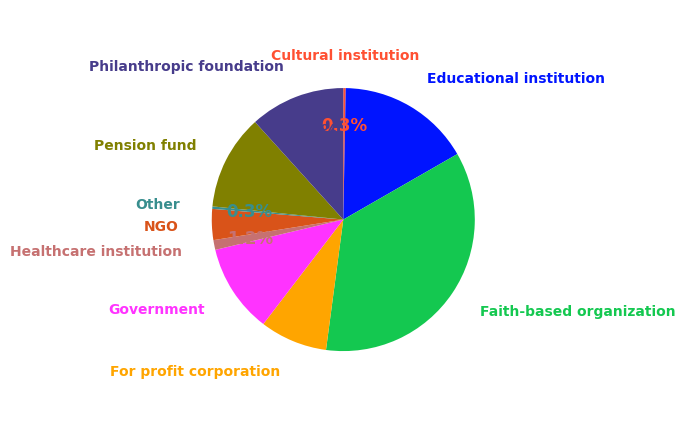

In [2]:

data = np.array([0.30, 16.40, 35.40, 8.30, 10.90, 1.20, 3.80, 0.30, 11.70, 11.70])
data = data / data.sum()

labels = ["Cultural institution", "Educational institution", "Faith-based organization",
          "For profit corporation", "Government", "Healthcare institution", "NGO",
          "Other", "Pension fund", "Philanthropic foundation"]

colours = [color_red, color_blue, color_green, color_orange, color_violet,
           color_salmon, color_matlab_darkorange, color_teal, color_lightyellow, color_slateblue]

fig, ax = plt.subplots(figsize=(7, 7))
wedges, _ = ax.pie(data, colors=colours, startangle=90, counterclock=False)

for i, w in enumerate(wedges):
    ang = np.deg2rad((w.theta1 + w.theta2) / 2)
    x, y = 0.72 * np.cos(ang), 0.72 * np.sin(ang)
    ax.text(x, y, f"{100*data[i]:.1f}%", color=colours[i], fontsize=12,
            fontweight="bold", ha="center", va="center")
    lx, ly = 1.25 * np.cos(ang), 1.25 * np.sin(ang)
    ha = "left" if lx > 0.1 else ("right" if lx < -0.1 else "center")
    ax.text(lx, ly, labels[i], color=colours[i], fontsize=10,
            fontweight="bold", ha=ha, va="center", clip_on=False)

ax.set_xlim(-2.1, 2.1)
ax.set_ylim(-1.6, 1.6)
ax.set_aspect("equal")
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()



## 2. Institutional ownership: implied market values and concentration

`chap6_institutional1.m` and `chap6_institutional2.m`. Both scripts are
`disp()`-only in the source (no figure) — reproduced here as printed
tables. The first backs out each country's implied total equity market
value from a listed institutional-investor AUM figure and its known
institutional-ownership share (`z = x / y`); the second tabulates
cumulative concentration (top-10 shares and their running total) for four
different investor-type breakdowns.


In [3]:

x = np.array([1299, 1031, 915.56, 569.29, 298.32])
y = np.array([8.36, 6.30, 5.80, 3.66, np.nan]) / 100
z = x / y
z_mean = np.nanmean(z)

tbl = pd.DataFrame({"AUM (USD bn)": x, "Institutional share": y, "Implied market value": z})
print(tbl.round(2).to_string(index=False))
print()
print(f"Mean implied market value (of first 4 countries): {z_mean:,.2f}")
print(f"x[4] / z_mean (5th country's AUM as a share of the average market): {x[4] / z_mean:.4f}")
print(f"x[4] / (x[3] * y[3]) (5th country's AUM relative to the 4th country's implied market): {x[4] / (x[3] * y[3]):.4f}")


 AUM (USD bn)  Institutional share  Implied market value
      1299.00                 0.08              15538.28
      1031.00                 0.06              16365.08
       915.56                 0.06              15785.52
       569.29                 0.04              15554.37
       298.32                  NaN                   NaN

Mean implied market value (of first 4 countries): 15,810.81
x[4] / z_mean (5th country's AUM as a share of the average market): 0.0189
x[4] / (x[3] * y[3]) (5th country's AUM relative to the 4th country's implied market): 14.3175


In [4]:

groups = {
    "Group 1": [9.80, 6.88, 5.44, 3.71, 1.93, 1.55, 1.48, 1.41, 1.39, 1.08],
    "Group 2": [3.15, 2.47, 2.05, 1.19, 1.16, 1.01, 0.84, 0.67, 0.58, 0.53],
    "Group 3": [0.78, 0.68, 0.65, 0.61, 0.48, 0.43, 0.39, 0.37, 0.32, 0.32],
    "Group 4": [0.13, 0.12, 0.12, 0.09, 0.08, 0.08, 0.07, 0.07, 0.06, 0.05],
}

for name, x in groups.items():
    x = np.array(x)
    y = np.cumsum(x)
    tbl = pd.DataFrame({"Share (%)": x, "Cumulative (%)": y})
    print(f"--- {name} ---")
    print(tbl.round(2).to_string(index=False))
    print("-" * 40)


--- Group 1 ---
 Share (%)  Cumulative (%)
      9.80            9.80
      6.88           16.68
      5.44           22.12
      3.71           25.83
      1.93           27.76
      1.55           29.31
      1.48           30.79
      1.41           32.20
      1.39           33.59
      1.08           34.67
----------------------------------------
--- Group 2 ---
 Share (%)  Cumulative (%)
      3.15            3.15
      2.47            5.62
      2.05            7.67
      1.19            8.86
      1.16           10.02
      1.01           11.03
      0.84           11.87
      0.67           12.54
      0.58           13.12
      0.53           13.65
----------------------------------------
--- Group 3 ---
 Share (%)  Cumulative (%)
      0.78            0.78
      0.68            1.46
      0.65            2.11
      0.61            2.72
      0.48            3.20
      0.43            3.63
      0.39            4.02
      0.37            4.39
      0.32            4.71
      


## 3. Institutional ownership by country

`chap6_institutional3.m`. Non-domestic/institutional-investor ownership
shares by country from `chap6_institutional_ownership.xlsx` (`Stats`
sheet, matching the MATLAB script's `sheet=2`).


In [5]:

own = pd.read_excel(f"{DATA_DIR}/chap6_institutional_ownership.xlsx", sheet_name="Stats", header=None)
row0 = own.iloc[0, 2:].tolist()
row1 = own.iloc[1, 2:].tolist()
cols = [f"{a} ({b})" if isinstance(b, str) and b.strip() else a for a, b in zip(row0, row1)]
country = own.iloc[2:, 1].reset_index(drop=True)
percentage = own.iloc[2:, 2:].reset_index(drop=True)
percentage.columns = cols
percentage = percentage.astype(float)
percentage.insert(0, "Country", country)

pct_display = percentage.copy()
for c in pct_display.columns[1:]:
    pct_display[c] = 100 * pct_display[c]

print(pct_display.round(1).to_string(index=False))


       Country  Corporations  Public sector  Strategic individuals  Institutional investors  Other free-float  Non-domestic (Total)  Non-domestic (% Instit.)
     Argentina          25.0           17.0                   17.0                     10.0              31.0                  10.0                      41.7
     Australia           5.0            2.0                    6.0                     27.0              60.0                  16.0                      80.0
       Austria          21.0           23.0                    6.0                     23.0              27.0                  15.0                      55.6
       Belgium          26.0            3.0                    7.0                     35.0              29.0                  33.0                      70.2
        Brazil          29.0           10.0                    8.0                     27.0              26.0                  17.0                      56.7
      Bulgaria          75.0            2.0         


## 4. Aggregate proxy-voting outcomes, 2018-2022

`chap6_vote1.m` and `chap6_vote2.m`. Two hardcoded illustrative series:
the average support level for E+S vs. G-related shareholder resolutions,
and the average pass rate of shareholder-sponsored proposals overall.


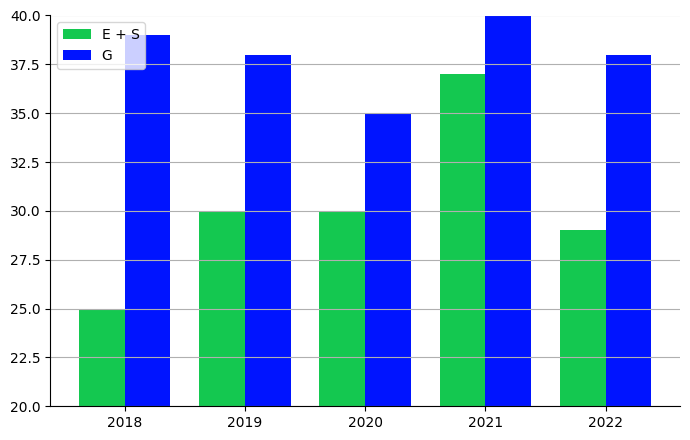

In [6]:

data = np.array([[0.25, 0.30, 0.30, 0.37, 0.29],
                  [0.39, 0.38, 0.35, 0.40, 0.38]]).T * 100

years = ["2018", "2019", "2020", "2021", "2022"]
x = np.arange(len(years))

fig, ax = plt.subplots(figsize=(7, 4.5))
w = 0.38
ax.bar(x - w/2, data[:, 0], width=w, color=color_green, label="E + S")
ax.bar(x + w/2, data[:, 1], width=w, color=color_blue, label="G")
ax.grid(True, axis="y")
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_ylim(20, 40)
ax.legend(loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()


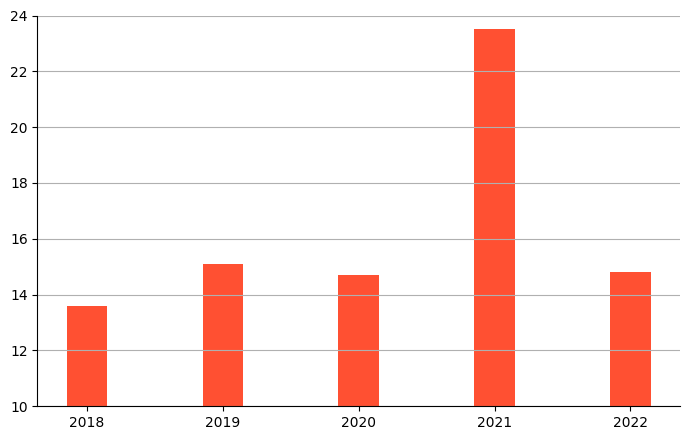

In [7]:

data = np.array([0.136, 0.151, 0.147, 0.235, 0.148]) * 100
years = ["2018", "2019", "2020", "2021", "2022"]
x = np.arange(len(years))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(x, data, width=0.30, color=color_red)
ax.grid(True, axis="y")
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_ylim(10, 24)
ax.spines[["top", "right"]].set_visible(False)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()



## 5. The ShareAction "Voting Matters" dataset, 2019-2023

The remaining scripts (`chap6_voting_ShareAction*.m`, `chap6_voting_
asset_owner1.m`) all draw on ShareAction's annual "Voting Matters" survey
of how the world's largest asset managers voted on environmental, social,
and governance shareholder resolutions. Two helper readers below mirror
the two data shapes used throughout: the per-year resolution-level detail
(`Resolutions` sheet: one row per resolution, with its vote % / topic /
sponsor), and the multi-year, ticker-aligned wide panel (merged workbook's
`Feuil1` sheet: one row per asset manager, AUM and vote-support columns
per year).


In [8]:

def load_resolutions(year):
    df = pd.read_excel(f"{DATA_DIR}/chap6_voting_ShareAction_{year}.xlsx",
                        sheet_name="Resolutions", header=0)
    df.columns = ["voting", "topic", "sponsor"]
    return df

def load_panel(years_label):
    df = pd.read_excel(f"{DATA_DIR}/chap6_voting_ShareAction_{years_label}.xlsx",
                        sheet_name="Feuil1", header=[0, 1])
    return df

panel_2019_2022 = load_panel("2019_2022")
panel_2019_2023 = load_panel("2019_2023")
resolutions = {y: load_resolutions(y) for y in [2019, 2020, 2021, 2022, 2023]}

print("2019-2022 panel:", panel_2019_2022.shape, " 2019-2023 panel:", panel_2019_2023.shape)
for y, r in resolutions.items():
    print(f"{y}: {len(r)} resolutions, topics = {sorted(r['topic'].unique())}")


2019-2022 panel: (84, 20)  2019-2023 panel: (85, 25)
2019: 64 resolutions, topics = ['E']
2020: 102 resolutions, topics = ['E', 'L', 'S']
2021: 169 resolutions, topics = ['E', 'G', 'S', 'Say']
2022: 288 resolutions, topics = ['E', 'Pay', 'S', 'Say']
2023: 274 resolutions, topics = ['E', 'L', 'S', 'Say on Climate']



### 5.1 Dataset coverage

`chap6_voting_ShareAction1.m`. How many asset managers report AUM in all
four years (2019-2022 panel) vs. vote in all five years (2019-2023 panel).


In [9]:

aum_cols_4 = [("AUM", y) for y in [2019, 2020, 2021, 2022]]
n_any_aum = panel_2019_2022[aum_cols_4].notna().any(axis=1).sum()
n_all_aum = panel_2019_2022[aum_cols_4].notna().all(axis=1).sum()
print(f"Managers reporting AUM in at least one of 2019-2022: {n_any_aum}")
print(f"Managers reporting AUM in all four of 2019-2022:     {n_all_aum}")

vote_cols_5 = [("Overall", y) for y in [2019, 2020, 2021, 2022, 2023]]
n_any_vote = panel_2019_2023[vote_cols_5].notna().any(axis=1).sum()
n_all_vote = panel_2019_2023[vote_cols_5].notna().all(axis=1).sum()
print(f"Managers with an overall vote rate in at least one of 2019-2023: {n_any_vote}")
print(f"Managers with an overall vote rate in all five of 2019-2023:     {n_all_vote}")
tickers_all5 = panel_2019_2023.loc[panel_2019_2023[vote_cols_5].notna().all(axis=1), ("Ticker", "Unnamed: 0_level_1")]
print("Tickers voting in all 5 years:", tickers_all5.tolist())


Managers reporting AUM in at least one of 2019-2022: 84
Managers reporting AUM in all four of 2019-2022:     26
Managers with an overall vote rate in at least one of 2019-2023: 85
Managers with an overall vote rate in all five of 2019-2023:     25
Tickers voting in all 5 years: ['APG AM', 'AXA IM', 'Abrdn', 'Allianz GI', 'Amundi AM', 'BNP PAM', 'BlackRock', 'Capital Group', 'DWS', 'Fidelity Investments', 'Generali Insurance AM', 'Goldman Sachs AM', 'HSBC Global AM', 'Invesco', 'J.P. Morgan AM', 'Legal & General', 'M&G IM', 'Ninety One', 'Northern Trust AM', 'SSGA', 'Schroders', 'T. Rowe Price', 'UBS AM', 'Vanguard', 'Wellington Management']



### 5.2 Vote-support distribution by year

`chap6_voting_ShareAction2.m`. For each year's shareholder-sponsored,
non-"Say"-topic resolutions: sample size, pass-rate (>= 50%), mean support,
support quantiles, and mean support by topic (E / S / Pay).


In [10]:

def shareholder_non_say(df):
    cnd = (df["topic"] != "Say") & df["voting"].notna() & (df["sponsor"] == "Shareholder")
    return df.loc[cnd]

years = [2019, 2020, 2021, 2022, 2023]
stats = pd.DataFrame(index=[
    "n", "n >= 50%", "% >= 50%", "mean (%)", "q10", "q25", "q75", "q90",
    "mean E (%)", "mean S (%)", "mean Pay (%)"], columns=years, dtype=float)

for y in years:
    sub = shareholder_non_say(resolutions[y])
    rate = sub["voting"] / 100
    stats.loc["n", y] = len(rate)
    stats.loc["n >= 50%", y] = (rate >= 0.5).sum()
    stats.loc["% >= 50%", y] = 100 * (rate >= 0.5).mean()
    stats.loc["mean (%)", y] = 100 * rate.mean()
    stats.loc["q10", y] = 100 * rate.quantile(0.10)
    stats.loc["q25", y] = 100 * rate.quantile(0.25)
    stats.loc["q75", y] = 100 * rate.quantile(0.75)
    stats.loc["q90", y] = 100 * rate.quantile(0.90)
    stats.loc["mean E (%)", y] = 100 * sub.loc[sub["topic"] == "E", "voting"].mean() / 100
    stats.loc["mean S (%)", y] = 100 * sub.loc[sub["topic"] == "S", "voting"].mean() / 100
    stats.loc["mean Pay (%)", y] = 100 * sub.loc[sub["topic"] == "Pay", "voting"].mean() / 100

print(stats.round(1).to_string())


              2019   2020   2021   2022   2023
n             64.0  102.0  144.0  249.0  261.0
n >= 50%       3.0   15.0   29.0   37.0    8.0
% >= 50%       4.7   14.7   20.1   14.9    3.1
mean (%)      28.2   29.9   32.9   29.9   23.2
q10            6.8    9.3    7.3    9.5    8.3
q25           17.2   13.1   12.1   13.5   13.1
q75           37.6   42.6   42.1   40.3   31.5
q90           41.7   54.7   80.9   57.2   37.5
mean E (%)    28.2   35.8   41.8   31.6   22.2
mean S (%)     NaN   24.5   28.8   27.4   22.4
mean Pay (%)   NaN    NaN    NaN   32.7    NaN



### 5.3 Histograms of vote-support levels

`chap6_voting_ShareAction3.m` (2019-2022) and `chap6_voting_ShareAction3b.m`
(2019-2020 pooled, then 2021/2022/2023 individually).


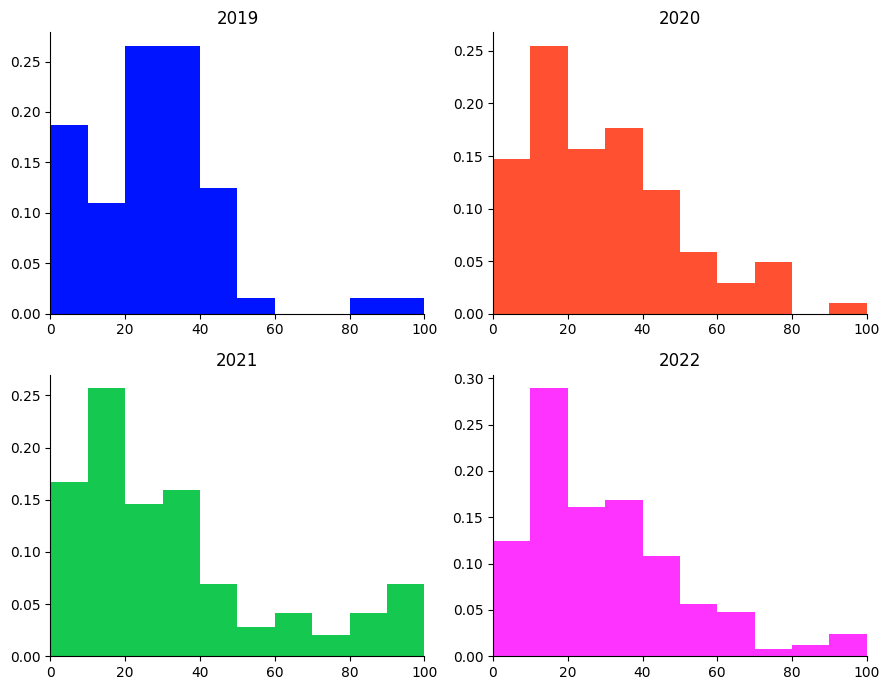

In [11]:

fig, axes = plt.subplots(2, 2, figsize=(9, 7))
colours = [color_blue, color_red, color_green, color_violet]
titles = ["2019", "2020", "2021", "2022"]
edges = np.arange(0, 101, 10)

for i, (ax, y, c, t) in enumerate(zip(axes.flat, years[:4], colours, titles)):
    rate = shareholder_non_say(resolutions[y])["voting"]
    weights = np.ones_like(rate) / len(rate)
    ax.hist(rate, bins=edges, weights=weights, color=c)
    ax.set_title(t)
    ax.set_xlim(0, 100)
    ax.set_xticks(np.arange(0, 101, 20))
    ax.spines[["top", "right"]].set_visible(False)

fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()


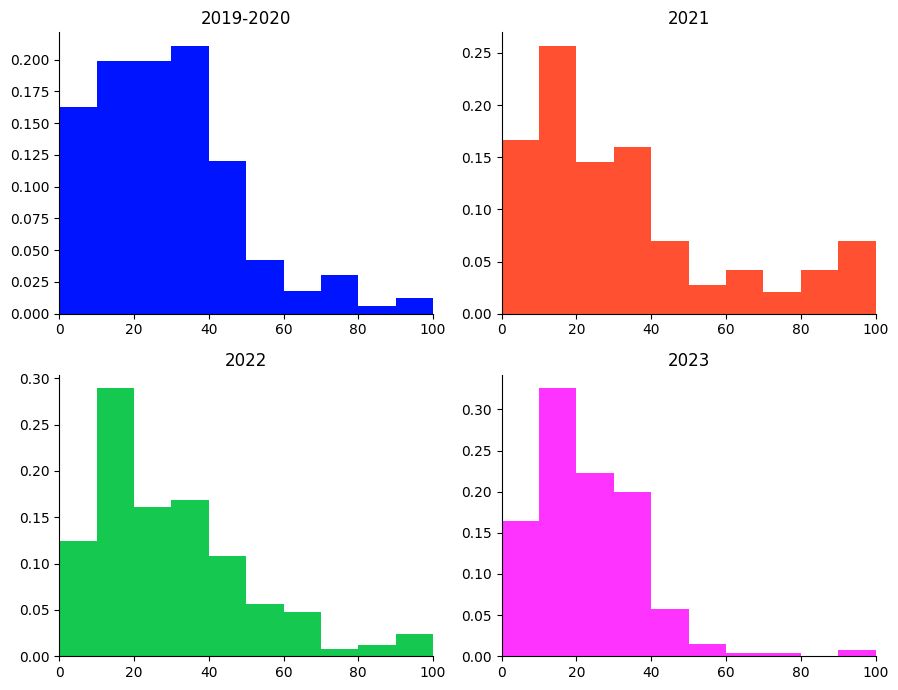

In [12]:

pooled = {
    "2019-2020": pd.concat([shareholder_non_say(resolutions[2019])["voting"],
                             shareholder_non_say(resolutions[2020])["voting"]]),
    "2021": shareholder_non_say(resolutions[2021])["voting"],
    "2022": shareholder_non_say(resolutions[2022])["voting"],
    "2023": shareholder_non_say(resolutions[2023])["voting"],
}
colours2 = [color_blue, color_red, color_green, color_violet]

fig, axes = plt.subplots(2, 2, figsize=(9, 7))
for ax, (t, rate), c in zip(axes.flat, pooled.items(), colours2):
    weights = np.ones_like(rate) / len(rate)
    ax.hist(rate, bins=edges, weights=weights, color=c)
    ax.set_title(t)
    ax.set_xlim(0, 100)
    ax.set_xticks(np.arange(0, 101, 20))
    ax.spines[["top", "right"]].set_visible(False)

fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()



### 5.4 AUM-weighted vs. unweighted average support

`chap6_voting_ShareAction4.m`. For each topic (overall / environment /
social / pay / lobbying), the simple mean vote-support level across
managers vs. the AUM-weighted average — a missing 2023 AUM figure is
filled with the manager's 2022 AUM, matching the source.


In [13]:

aum = panel_2019_2023["AUM"].copy()
aum[2023] = aum[2023].fillna(aum[2022])

topic_cols = {
    "Overall": panel_2019_2023["Overall"],
    "Environment": panel_2019_2023["Environment"],
    "Social": panel_2019_2023["Social"],
}
# Pay/Lobbying: 2022 = Pay column, 2023 = Lobbying column, 2019-2021 undefined
pay_lob = pd.DataFrame(index=panel_2019_2023.index, columns=years, dtype=float)
pay_lob[2022] = panel_2019_2023[("Pay", 2022)]
pay_lob[2023] = panel_2019_2023[("Lobbying", 2023)]
topic_cols["Pay/Lobbying"] = pay_lob

for label, vote_df in topic_cols.items():
    stats = pd.DataFrame(index=["mean (%)", "AUM-weighted mean (%)"], columns=years, dtype=float)
    for y in years:
        pair = pd.concat([aum[y], vote_df[y]], axis=1, keys=["aum", "vote"]).dropna()
        if pair.empty:
            continue
        w = pair["aum"] / pair["aum"].sum()
        stats.loc["mean (%)", y] = 100 * pair["vote"].mean()
        stats.loc["AUM-weighted mean (%)", y] = 100 * (w * pair["vote"]).sum()
    print(f"--- {label} ---")
    print(stats.round(1).to_string())
    print()


--- Overall ---
                       2019  2020  2021  2022  2023
mean (%)               45.8  57.4  58.9  65.0  65.2
AUM-weighted mean (%)  32.7  42.1  47.6  46.5  39.8

--- Environment ---
                       2019  2020  2021  2022  2023
mean (%)               45.8  61.0  66.0  64.8  64.0
AUM-weighted mean (%)  32.7  44.7  55.8  48.8  39.8

--- Social ---
                       2019  2020  2021  2022  2023
mean (%)                NaN  53.3  55.2  62.7  64.6
AUM-weighted mean (%)   NaN  39.0  43.7  44.3  39.0

--- Pay/Lobbying ---
                       2019  2020  2021  2022  2023
mean (%)                NaN   NaN   NaN  71.5  69.9
AUM-weighted mean (%)   NaN   NaN   NaN  47.8  42.1




### 5.5 Vote support by region and topic

`chap6_voting_ShareAction5.m` (simple mean) and `chap6_voting_
ShareAction6.m` (AUM-weighted mean): US / Europe / UK / World, by topic,
by year.


In [14]:

europe_country = ["Finland", "France", "Germany", "Italy", "Luxembourg",
                   "Netherlands", "Spain", "Sweden", "Switzerland"]
country = panel_2019_2023["Country"]["Unnamed: 2_level_1"]

region_masks = {
    "US": country == "US",
    "EU": country.isin(europe_country),
    "UK": country == "UK",
    "WD": pd.Series(True, index=country.index),
}

def region_topic_year_stats(weighted):
    out = np.zeros((4, 5, 4))
    for ti, (label, vote_df) in enumerate(topic_cols.items()):
        for yi, y in enumerate(years):
            for ri, (rname, mask) in enumerate(region_masks.items()):
                pair = pd.concat([aum.loc[mask, y], vote_df.loc[mask, y]], axis=1,
                                  keys=["aum", "vote"]).dropna()
                if pair.empty:
                    continue
                if weighted:
                    w = pair["aum"] / pair["aum"].sum()
                    out[ri, yi, ti] = (w * pair["vote"]).sum()
                else:
                    out[ri, yi, ti] = pair["vote"].mean()
    return out

freq1 = region_topic_year_stats(weighted=False)
freq2 = region_topic_year_stats(weighted=True)
region_labels = ["US", "EU", "UK", "WD"]
topic_titles = ["Overall", "Environment", "Social", "Pay/Lobbying"]
year_colours = [color_blue, color_green, color_red, color_violet, color_teal]


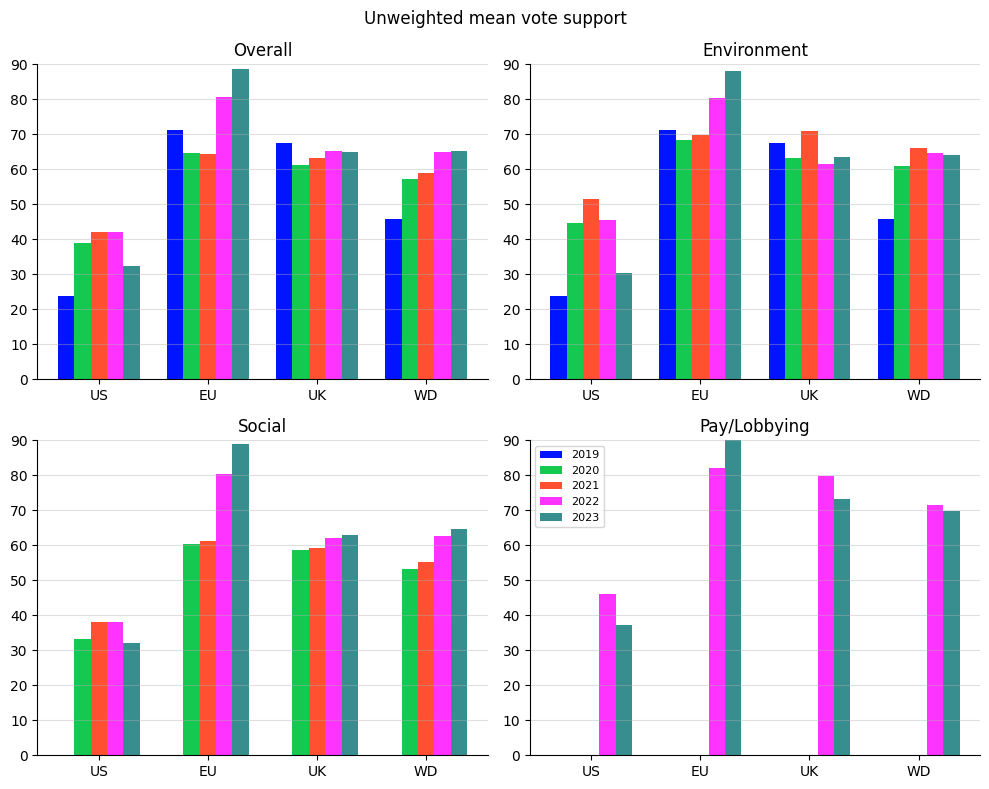

In [15]:

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ti, (ax, title) in enumerate(zip(axes.flat, topic_titles)):
    x = np.arange(4)
    w = 0.15
    for yi, y in enumerate(years):
        ax.bar(x + (yi - 2) * w, 100 * freq1[:, yi, ti], width=w, color=year_colours[yi])
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(region_labels)
    ax.set_ylim(0, 90)
    ax.grid(True, axis="y", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)
    if ti == 3:
        ax.legend([str(y) for y in years], fontsize=8, loc="upper left")

fig.suptitle("Unweighted mean vote support")
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()


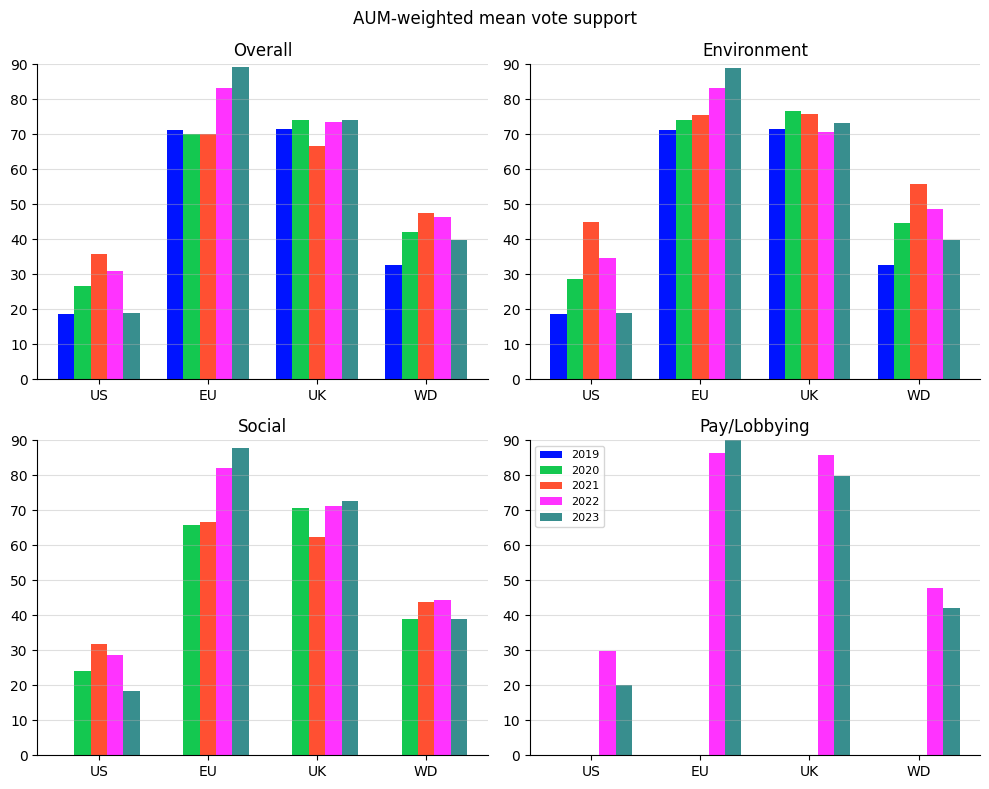

In [16]:

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ti, (ax, title) in enumerate(zip(axes.flat, topic_titles)):
    x = np.arange(4)
    w = 0.15
    for yi, y in enumerate(years):
        ax.bar(x + (yi - 2) * w, 100 * freq2[:, yi, ti], width=w, color=year_colours[yi])
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(region_labels)
    ax.set_ylim(0, 90)
    ax.grid(True, axis="y", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)
    if ti == 3:
        ax.legend([str(y) for y in years], fontsize=8, loc="upper left")

fig.suptitle("AUM-weighted mean vote support")
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()



### 5.6 Overall vote support by manager, 2019-2023

`chap6_voting_ShareAction7.m`. One line per asset manager tracking its
overall vote-support rate over the five years.


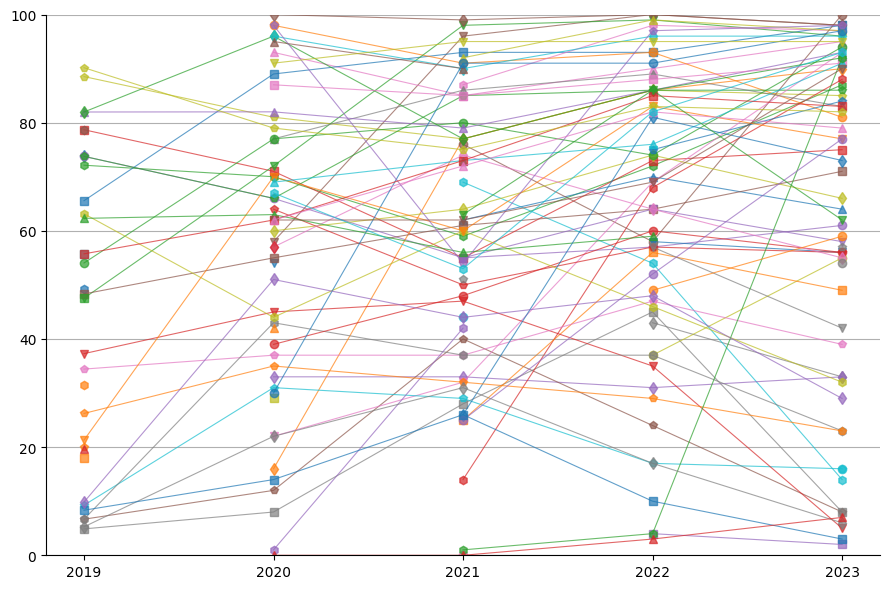

In [17]:

overall = panel_2019_2023["Overall"]

fig, ax = plt.subplots(figsize=(9, 6))
markers = ["d", "p", "h", "s", "o", "v", "^"]
for i, (_, row) in enumerate(overall.iterrows()):
    ax.plot(years, 100 * row.values, "-", marker=markers[i % len(markers)],
            markersize=6, linewidth=0.8, alpha=0.7)

ax.set_xlim(2018.8, 2023.2)
ax.set_xticks(years)
ax.set_ylim(0, 100)
ax.grid(True, axis="y")
ax.spines[["top", "right"]].set_visible(False)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()



### 5.7 Top asset managers: ranked by AUM and by vote support

`chap6_voting_ShareAction8.m` (top 25 by 2022 AUM, from the 2019-2023
panel) and `chap6_voting_ShareAction9.m` (top 25 by 2022 overall vote
support, from the 2019-2022 panel). `chap6_voting_ShareAction10.m` repeats
`ShareAction9`'s ranking with `nS = 68` instead of 25 — essentially the
full universe rather than a top-25 cut — and is not rebuilt separately.


In [18]:

nS = 25
pivot_year = 2022

rank_var = panel_2019_2023[("AUM", pivot_year)].fillna(0)
top_idx = rank_var.sort_values(ascending=False).head(nS).index

cols = [("Ticker", "Unnamed: 0_level_1"), ("Country", "Unnamed: 2_level_1"), ("AUM", pivot_year)]
tbl8 = panel_2019_2023.loc[top_idx, cols].copy()
tbl8.columns = ["Ticker", "Country", "AUM 2022"]
for y in years:
    tbl8[f"Overall {y}"] = 100 * panel_2019_2023.loc[top_idx, ("Overall", y)].values
tbl8 = tbl8.reset_index(drop=True)
tbl8.index += 1
print(tbl8.round(1).to_string())


                   Ticker      Country  AUM 2022  Overall 2019  Overall 2020  Overall 2021  Overall 2022  Overall 2023
1               BlackRock           US   10014.0           6.7          12.0          40.0          24.0           8.0
2                Vanguard           US    8274.0           8.3          14.0          26.0          10.0           3.0
3    Fidelity Investments           US    4520.0           9.3          31.0          29.0          17.0          16.0
4                    SSGA           US    4140.0          26.2          35.0          32.0          29.0          23.0
5          J.P. Morgan AM           US    2742.0           6.7          43.0          37.0          37.0          23.0
6           Capital Group           US    2716.0           4.9           8.0          28.0          45.0           8.0
7               Amundi AM       France    2348.0          65.6          89.0          93.0          93.0          98.0
8        Goldman Sachs AM           US    2218.0

In [19]:

nS = 25
pivot_year = 2022

rank_var = panel_2019_2022[("Overall", pivot_year)].fillna(0)
top_idx = rank_var.sort_values(ascending=False).head(nS).index

cols9 = [("Ticker", "Unnamed: 0_level_1"), ("Country", "Unnamed: 2_level_1"), ("AUM", pivot_year)]
tbl9 = panel_2019_2022.loc[top_idx, cols9].copy()
tbl9.columns = ["Ticker", "Country", "AUM 2022"]
tbl9["Overall 2022"] = 100 * panel_2019_2022.loc[top_idx, ("Overall", pivot_year)].values
tbl9["Environment 2022"] = 100 * panel_2019_2022.loc[top_idx, ("Environment", pivot_year)].values
tbl9["Social 2022"] = 100 * panel_2019_2022.loc[top_idx, ("Social", pivot_year)].values
tbl9["Pay 2022"] = 100 * panel_2019_2022.loc[top_idx, ("Pay", pivot_year)].values
tbl9 = tbl9.reset_index(drop=True)
tbl9.index += 1
print(tbl9.round(1).to_string())


               Ticker      Country  AUM 2022  Overall 2022  Environment 2022  Social 2022  Pay 2022
1           Achmea IM  Netherlands     251.0         100.0             100.0        100.0     100.0
2            Impax AM           UK      56.0         100.0             100.0        100.0     100.0
3                  MN  Netherlands     193.0          99.0              97.0        100.0     100.0
4             BNP PAM       France     761.0          99.0              97.0        100.0     100.0
5            Candriam   Luxembourg     180.0          98.0              97.0         99.0     100.0
6                PGGM  Netherlands     331.0          97.0              93.0        100.0      97.0
7                 Man           UK     149.0          96.0              98.0         94.0      98.0
8              Robeco  Netherlands     228.0          95.0              94.0         94.0     100.0
9           Amundi AM       France    2348.0          93.0              93.0         92.0      98.0



### 5.8 "Say on Pay" (2022) and "Say on Climate" (2023) resolutions

`chap6_voting_ShareAction11.m` (2022 "Say" resolutions) and `chap6_voting_
ShareAction11b.m` (2023 "Say on Climate" resolutions): individual
resolution support, sorted ascending, coloured by whether the resolution
was shareholder- or management-sponsored, against the 50% pass-line.
`chap6_voting_ShareAction11a.m` (identical to `ShareAction11.m` but for one
bar's fill colour) is not rebuilt separately; `chap6_voting_
ShareAction11c.m`'s summary statistics for both years are printed below.


--- 2022 Say ---
              n   mean   min   max
Shareholder   6  21.98   1.0  46.5
Management   30  89.17  51.0  99.9


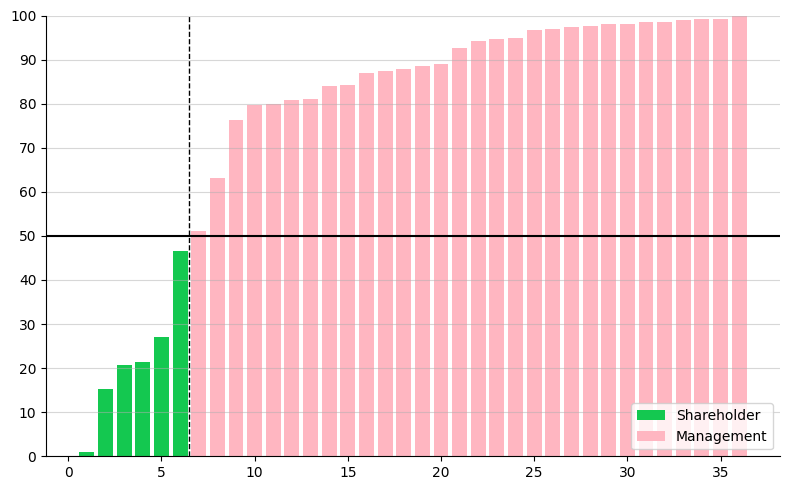

In [20]:

def say_resolution_chart(year, topic_label, colours):
    df = resolutions[year]
    sub = df.loc[df["topic"] == topic_label].sort_values("voting").reset_index(drop=True)
    mgmt = sub["sponsor"] == "Management"
    s = np.arange(1, len(sub) + 1)

    stats = pd.DataFrame({
        "n": [(~mgmt).sum(), mgmt.sum()],
        "mean": [sub.loc[~mgmt, "voting"].mean(), sub.loc[mgmt, "voting"].mean()],
        "min": [sub.loc[~mgmt, "voting"].min(), sub.loc[mgmt, "voting"].min()],
        "max": [sub.loc[~mgmt, "voting"].max(), sub.loc[mgmt, "voting"].max()],
    }, index=["Shareholder", "Management"])
    print(f"--- {year} {topic_label} ---")
    print(stats.round(2).to_string())

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(s[~mgmt], sub.loc[~mgmt, "voting"], color=colours[0], label="Shareholder")
    ax.bar(s[mgmt], sub.loc[mgmt, "voting"], color=colours[1], label="Management")
    ax.axhline(50, color=color_black, linewidth=1.5)
    ax.axvline(6.5, color=color_black, linewidth=1.0, linestyle="--")
    ax.set_ylim(0, 100)
    ax.set_yticks(np.arange(0, 101, 10))
    ax.grid(True, axis="y", alpha=0.5)
    ax.legend(loc="lower right")
    ax.spines[["top", "right"]].set_visible(False)
    fig.patch.set_facecolor("white")
    plt.tight_layout()
    plt.show()

say_resolution_chart(2022, "Say", (color_green, color_pink))


--- 2023 Say on Climate ---
              n   mean   min   max
Shareholder   6  19.68  16.6  24.4
Management   11  90.83  69.7  98.6


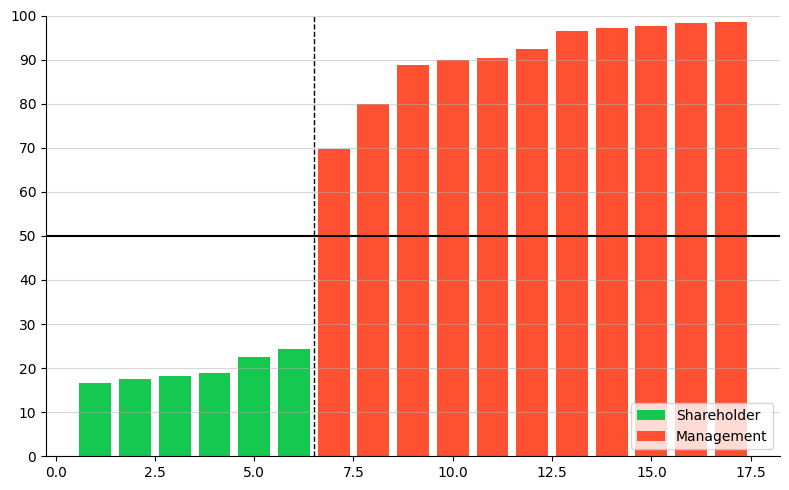

In [21]:

say_resolution_chart(2023, "Say on Climate", (color_green, color_red))



## 6. Top asset owners by assets under management

`chap6_voting_asset_owner1.m`. The largest pension funds and sovereign
wealth funds by total assets, from `chap6_voting_asset_owners.xlsx`.


In [22]:

owners = pd.read_excel(f"{DATA_DIR}/chap6_voting_asset_owners.xlsx", sheet_name="Feuil1", header=0)
owners.columns = ["Rank", "Name", "Country", "Assets", "Type", "Sigle"]
owners["Assets (USD bn)"] = owners["Assets"] / 1000
owners = owners[["Rank", "Name", "Country", "Assets (USD bn)", "Type", "Sigle"]]
print(owners.round(1).to_string(index=False))


 Rank                                           Name              Country  Assets (USD bn)         Type    Sigle
    1             Government Pension Investment Fund                Japan           1448.6 Pension Fund     GPIF
    2              Norges Bank Investment Management               Norway           1250.0          SWF     NBIM
    3                   China Investment Corporation                China           1149.0          SWF      CIC
    4                        SAFE Investment Company                China           1034.0          SWF     SAFE
    5                 Abu Dhabi Investment Authority United Arab Emirates            831.0          SWF     ADIA
    6                    Kuwait Investment Authority               Kuwait            769.0          SWF      KIA
    7                       National Pension Service          South Korea            706.5 Pension Fund      NPS
    8                            GIC Private Limited            Singapore            690.0      


## Summary

This notebook covers all 23 exercise scripts in `HSF/6. Engagement/`:
divestment commitments, institutional-ownership concentration, and the
real ShareAction "Voting Matters" proxy-voting panel (2019-2023) sliced
by year, topic, region, and AUM-weighting. No new packaging candidates —
every computation here is tied to this dataset's own specific column
layout (the per-year `Resolutions`/`Alphabetical` sheets, or the merged
multi-year panel), not a generic reusable primitive.
